In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [10]:
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [12]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [13]:
current_year = 2026
df["car_age"] = current_year - df["year"]

df.drop("year", axis=1, inplace=True)

df.head()

,name,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,Maruti 800 AC,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti Wagon R LXI Minor,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai Verna 1.6 SX,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun RediGO T Option,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda Amaze VX i-DTEC,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [15]:
df.drop("name", axis=1, inplace=True)

KeyError: "['name'] not found in axis"

In [16]:
print(df.columns.tolist())

['selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age']


In [17]:
le = LabelEncoder()

categorical_cols = ["fuel","seller_type","transmission","owner"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,60000,70000,4,1,1,0,19
1,135000,50000,4,1,1,0,19
2,600000,100000,1,1,1,0,14
3,250000,46000,4,1,1,0,9
4,450000,141000,1,1,1,2,12


In [18]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
rf_model = RandomForestRegressor()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [22]:
gb_model = GradientBoostingRegressor()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [23]:
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [24]:
def evaluate_model(y_test, pred):

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return rmse, r2


print("Random Forest:", evaluate_model(y_test, rf_pred))
print("Gradient Boosting:", evaluate_model(y_test, gb_pred))
print("XGBoost:", evaluate_model(y_test, xgb_pred))

Random Forest: (np.float64(393441.16764243366), 0.4927554894615399)
Gradient Boosting: (np.float64(397229.2679739755), 0.4829408414572156)
XGBoost: (np.float64(404248.56163504155), 0.4645058512687683)


In [26]:
def evaluate_model(y_test, pred):

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [27]:
print("Random Forest")
evaluate_model(y_test, rf_pred)

print("\nGradient Boosting")
evaluate_model(y_test, gb_pred)

print("\nXGBoost")
evaluate_model(y_test, xgb_pred)

Random Forest
RMSE: 393441.16764243366
R2 Score: 0.4927554894615399

Gradient Boosting
RMSE: 397229.2679739755
R2 Score: 0.4829408414572156

XGBoost
RMSE: 404248.56163504155
R2 Score: 0.4645058512687683


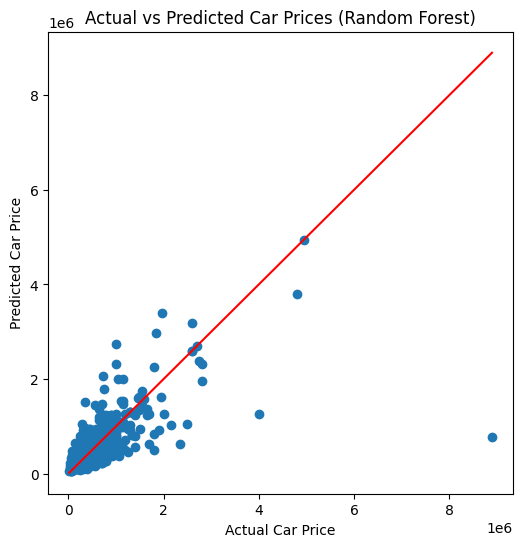

In [28]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Car Price")
plt.ylabel("Predicted Car Price")

plt.title("Actual vs Predicted Car Prices (Random Forest)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

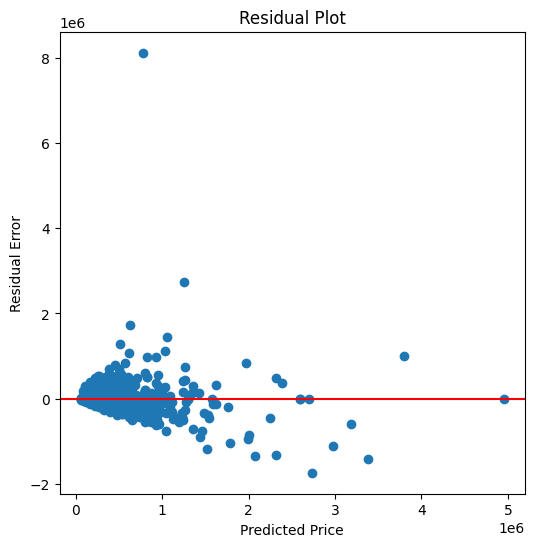

In [29]:
residuals = y_test - rf_pred

plt.figure(figsize=(6,6))
plt.scatter(rf_pred, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")

plt.title("Residual Plot")

plt.show()

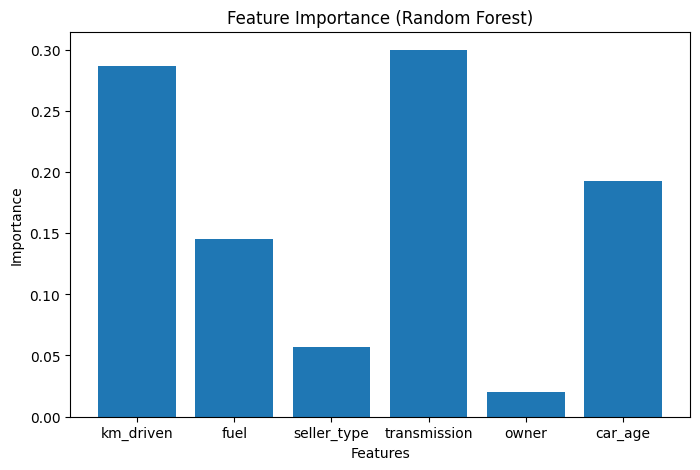

In [30]:
importance = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, importance)

plt.xlabel("Features")
plt.ylabel("Importance")

plt.title("Feature Importance (Random Forest)")

plt.show()

In [32]:
best_model = rf_model

In [37]:
def predict_car_price():

    year = int(input("Enter Manufacturing Year: "))
    km_driven = int(input("Enter Kilometers Driven: "))

    fuel = input("Fuel Type (CNG/Diesel/Petrol/LPG/Electric): ").strip()
    seller = input("Seller Type (Dealer/Individual): ").strip()
    transmission = input("Transmission (Manual/Automatic): ").strip()
    owner = input("Owner Type (First Owner/Second Owner/Third Owner/Fourth Owner/Test Drive Car): ").strip()

    # Calculate car age
    car_age = 2026 - year

    # Encoding mappings (must match dataset encoding)
    fuel_map = {
        "CNG":0,
        "Diesel":1,
        "Petrol":2,
        "LPG":3,
        "Electric":4
    }

    seller_map = {
        "Dealer":0,
        "Individual":1
    }

    transmission_map = {
        "Automatic":0,
        "Manual":1
    }

    owner_map = {
        "First Owner":0,
        "Second Owner":1,
        "Third Owner":2,
        "Fourth Owner":3,
        "Test Drive Car":4
    }

    # Convert text to numbers
    fuel = fuel_map[fuel]
    seller = seller_map[seller]
    transmission = transmission_map[transmission]
    owner = owner_map[owner]

    # Arrange input exactly like training data
    data = pd.DataFrame([[km_driven, fuel, seller, transmission, owner, car_age]],
                        columns=['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'car_age'])

    # Predict price
    prediction = best_ model.predict(data)

    print("\nEstimated Car Price: ₹", round(prediction[0],2))

predict_car_price()

Enter Manufacturing Year: 2014
Enter Kilometers Driven: 141000
Fuel Type (CNG/Diesel/Petrol/LPG/Electric): Diesel
Seller Type (Dealer/Individual): Individual 
Transmission (Manual/Automatic): Manual
Owner Type (First Owner/Second Owner/Third Owner/Fourth Owner/Test Drive Car): Second Owner

Estimated Car Price: ₹ 335525.0


In [38]:
import joblib

joblib.dump(best_model, "car_price_model.pkl")

['car_price_model.pkl']

In [39]:
from google.colab import files
files.download("car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
%%writefile app.py
import streamlit as st
import numpy as np
import joblib

model = joblib.load("car_price_model.pkl")

st.title("Used Car Price Prediction")

year = st.number_input("Manufacturing Year",1990,2026)
km_driven = st.number_input("Kilometers Driven",0,500000)

fuel = st.selectbox("Fuel Type",["CNG","Diesel","Petrol","LPG","Electric"])
seller = st.selectbox("Seller Type",["Dealer","Individual"])
transmission = st.selectbox("Transmission",["Manual","Automatic"])
owner = st.selectbox("Owner Type",
["First Owner","Second Owner","Third Owner","Fourth Owner","Test Drive Car"])

car_age = 2026 - year

fuel_map = {"CNG":0,"Diesel":1,"Petrol":2,"LPG":3,"Electric":4}
seller_map = {"Dealer":0,"Individual":1}
transmission_map = {"Automatic":0,"Manual":1}
owner_map = {"First Owner":0,"Second Owner":1,"Third Owner":2,"Fourth Owner":3,"Test Drive Car":4}

fuel = fuel_map[fuel]
seller = seller_map[seller]
transmission = transmission_map[transmission]
owner = owner_map[owner]

if st.button("Predict Price"):

    data = np.array([[km_driven,fuel,seller,transmission,owner,car_age]])

    prediction = model.predict(data)

    st.success(f"Estimated Car Price: ₹ {round(prediction[0],2)}")

Writing app.py


In [41]:
%%writefile requirements.txt
streamlit
numpy
pandas
scikit-learn
joblib
xgboost

Writing requirements.txt


In [42]:
from google.colab import files

files.download("app.py")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>